In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

In [7]:
df= pd.read_csv("healthcare_dataset.csv")
print(df.head())

            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18856.281306    

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [9]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [10]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [11]:
df['date'] = pd.date_range(start='2023-01-01', periods=len(df), freq='D')

In [12]:
ts = df.groupby('date').size().reset_index(name='admissions')
display(ts.head())

,date,admissions
0,2023-01-01,1
1,2023-01-02,1
2,2023-01-03,1
3,2023-01-04,1
4,2023-01-05,1


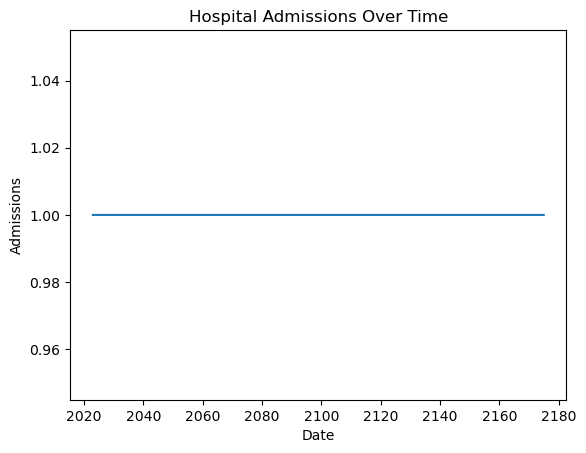

In [13]:
plt.figure()
plt.plot(ts['date'], ts['admissions'])
plt.title("Hospital Admissions Over Time")
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.show()

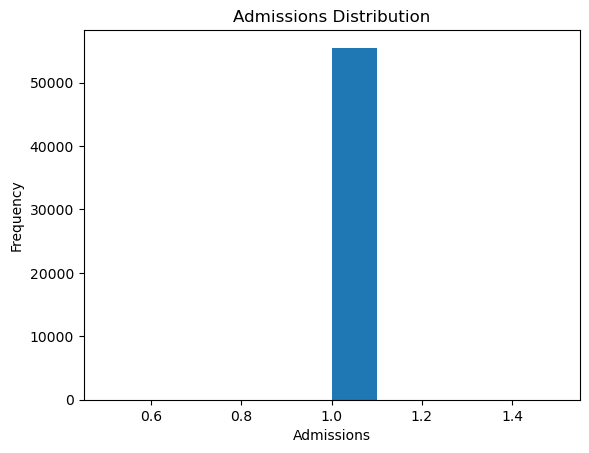

In [14]:
plt.figure()
plt.hist(ts['admissions'])
plt.title("Admissions Distribution")
plt.xlabel("Admissions")
plt.ylabel("Frequency")
plt.show()

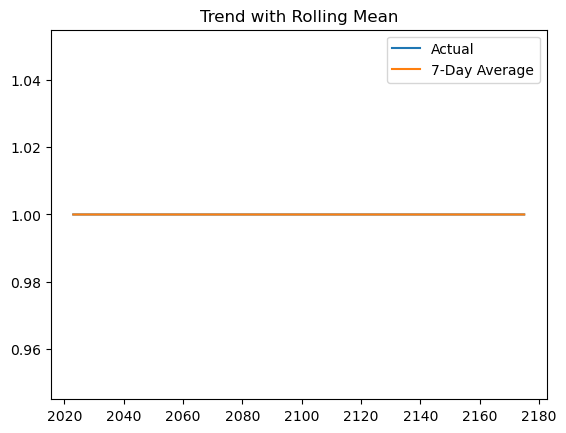

In [15]:
ts['rolling_mean'] = ts['admissions'].rolling(window=7).mean()

plt.figure()
plt.plot(ts['date'], ts['admissions'], label="Actual")
plt.plot(ts['date'], ts['rolling_mean'], label="7-Day Average")
plt.legend()
plt.title("Trend with Rolling Mean")
plt.show()

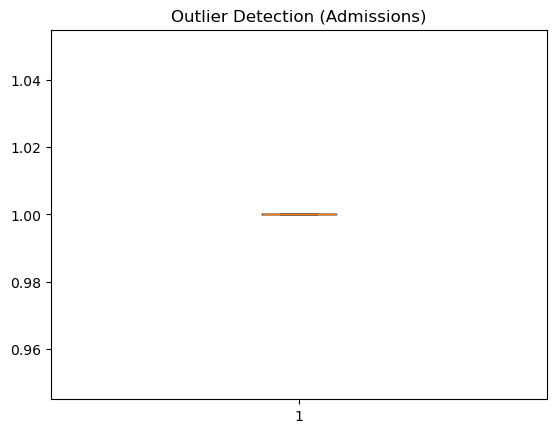

In [16]:
plt.figure()
plt.boxplot(ts['admissions'])
plt.title("Outlier Detection (Admissions)")
plt.show()

In [19]:
ts_arima = ts.copy()
ts_arima.set_index('date', inplace=True)
ts_arima = ts_arima.asfreq('D')

In [27]:
model_arima = ARIMA(ts_arima['admissions'], order=(1,1,1))
model_fit = model_arima.fit(method_kwargs={"maxiter": 3000})
forecast_arima = model_fit.forecast(steps=30)

C:\Users\Janani Shakthi\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


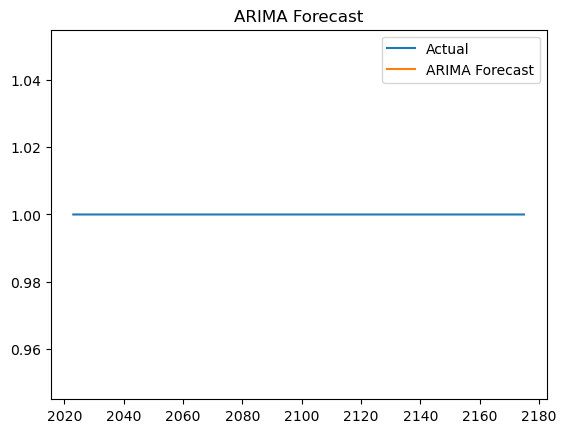

In [28]:
plt.figure()
plt.plot(ts_arima.index, ts_arima['admissions'], label="Actual")
plt.plot(future_dates_arima, forecast_arima, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [29]:
ts_prophet = ts.rename(columns={'date': 'ds', 'admissions': 'y'})

In [30]:
model_prophet = Prophet()
model_prophet.fit(ts_prophet)

In [31]:
future = model_prophet.make_future_dataframe(periods=30)
forecast_prophet = model_prophet.predict(future)

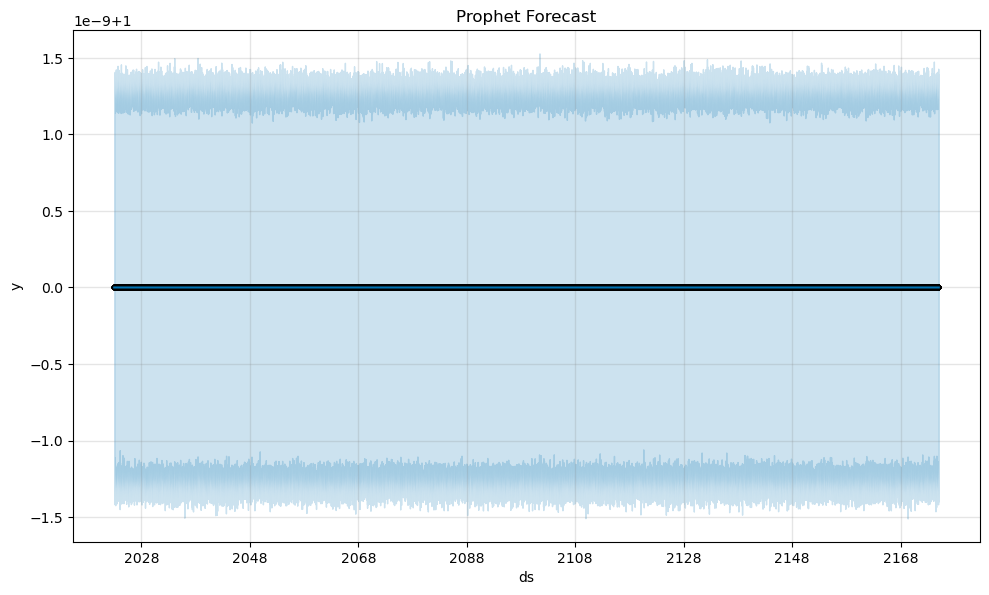

In [32]:
model_prophet.plot(forecast_prophet)
plt.title("Prophet Forecast")
plt.show()

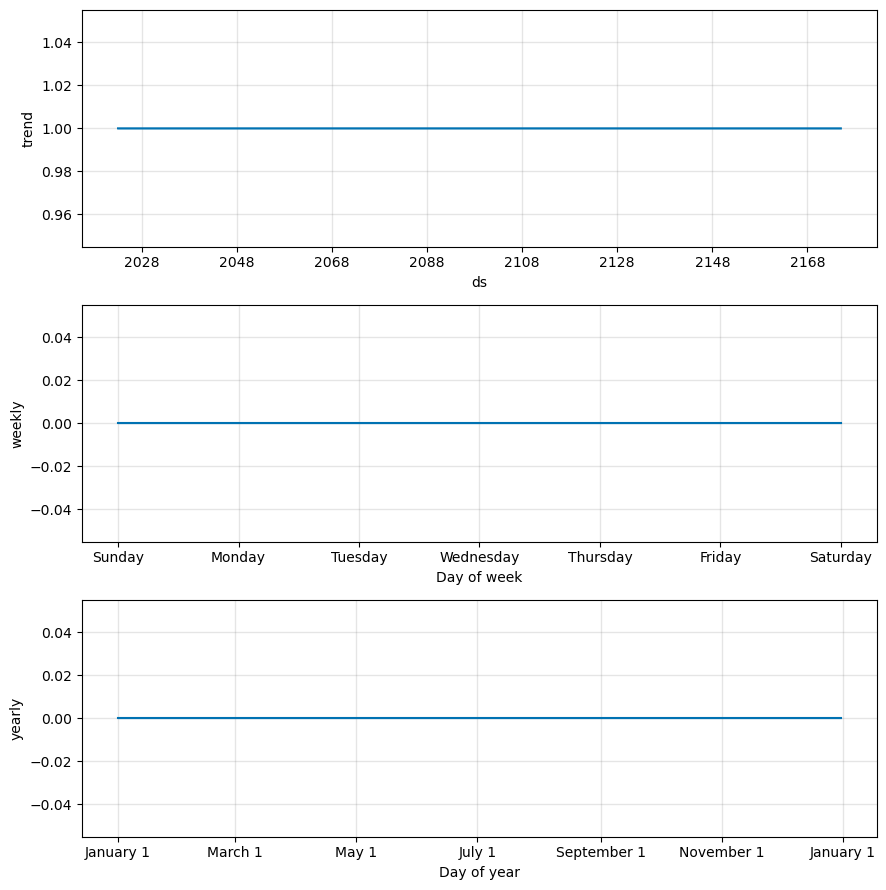

In [33]:
model_prophet.plot_components(forecast_prophet)
plt.show()


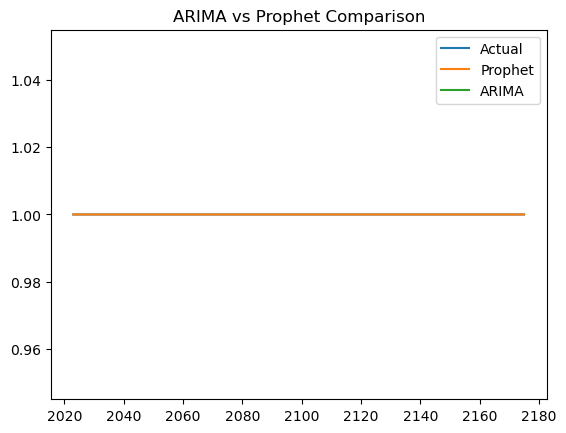

In [34]:
plt.figure()

# Actual
plt.plot(ts_prophet['ds'], ts_prophet['y'], label="Actual")

# Prophet
plt.plot(forecast_prophet['ds'], forecast_prophet['yhat'], label="Prophet")

# ARIMA
plt.plot(future_dates_arima, forecast_arima, label="ARIMA")

plt.legend()
plt.title("ARIMA vs Prophet Comparison")
plt.show()

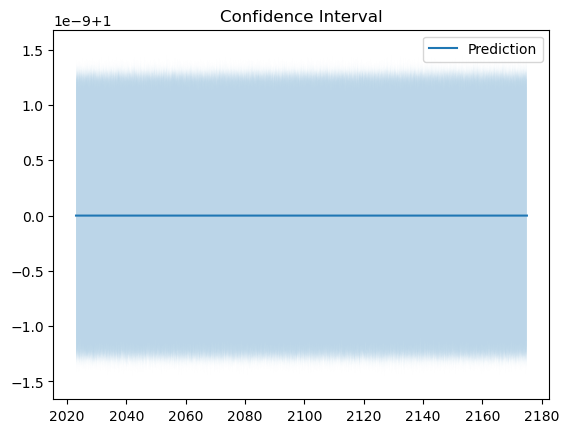

In [35]:
plt.figure()

plt.plot(forecast_prophet['ds'], forecast_prophet['yhat'], label="Prediction")

plt.fill_between(
    forecast_prophet['ds'],
    forecast_prophet['yhat_lower'],
    forecast_prophet['yhat_upper'],
    alpha=0.3
)

plt.legend()
plt.title("Confidence Interval")
plt.show()